In [ ]:
import pandas as pd
import numpy as np
import glob

import matplotlib.pyplot as plt

# Get all .dat files from the specified folder
dat_files = glob.glob(r'Z:\Vlad\heavyIV\202-2-ARed\Corner-B3\spectrum\*.dat')



In [ ]:
dat_files

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize an empty list to store the data
data_list = []

# Loop through each file and read the data
for file in dat_files:
    # Read the data from the file, skipping lines that start with '#'
    wavelength, data = np.genfromtxt(file, comments='#', usecols=(0, 1), unpack=True)
    # Check if there are peaks with intensity larger than 800
    if np.any(data > 800):
        data_list.append(data)
wavelength = wavelength/1e9


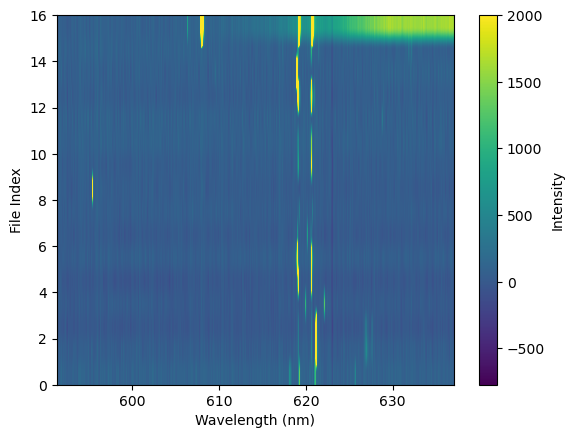

In [70]:
# Stack the data vertically to create a 2D numpy array
if data_list:
    data_array = np.vstack(data_list)

    # Plot the data using imshow
    plt.imshow(data_array, aspect='auto', extent=[wavelength.min(), wavelength.max(), 0, len(data_list)], vmax=2000)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('File Index')
    plt.colorbar(label='Intensity')
    plt.show()
else:
    print("No data with peaks larger than 800 found.")

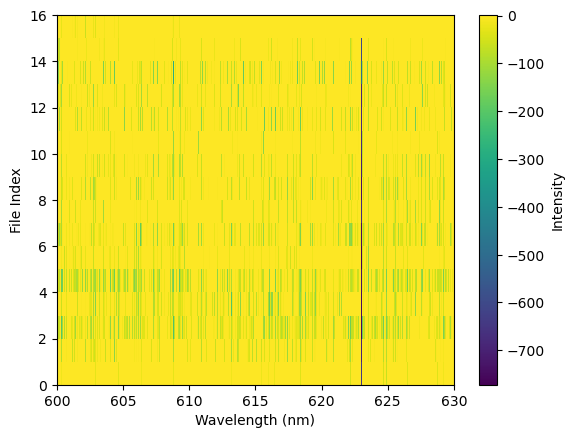

In [68]:
# Stack the data vertically to create a 2D numpy array
if data_list:
    data_array = np.vstack(data_list)

    # Define the wavelength range for zooming
    zoom_start = 600  # 620 nm
    zoom_end = 630    # 622 nm

    # Create a mask for the zoomed-in range
    mask = (wavelength >= zoom_start) & (wavelength <= zoom_end)

    # Plot the data using imshow with the zoomed-in range
    plt.imshow(data_array[:, mask], aspect='auto', extent=[zoom_start, zoom_end, 0, len(data_list)], vmax=1, interpolation='nearest')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('File Index')
    plt.colorbar(label='Intensity')
    plt.xlim(zoom_start, zoom_end)
    plt.show()
else:
    print("No data with peaks larger than 800 found.")

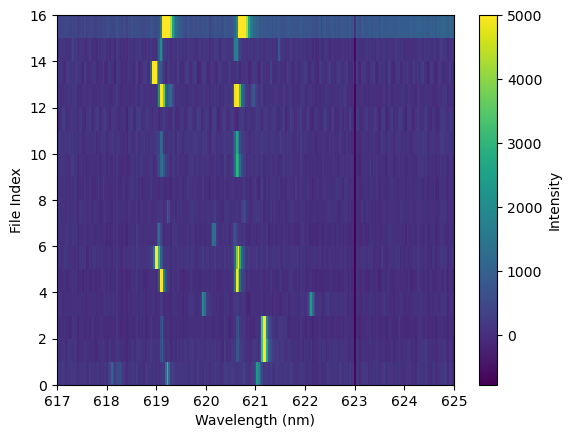

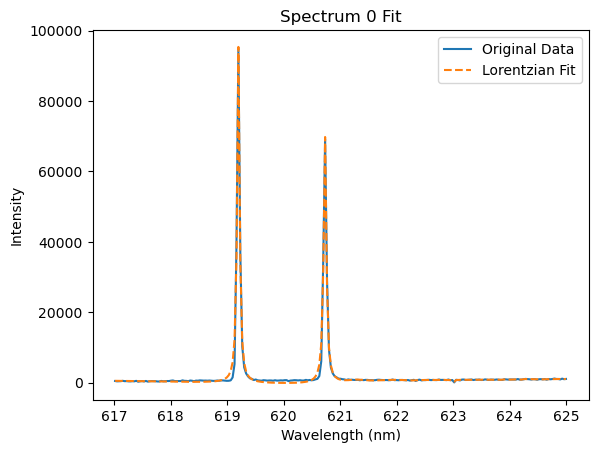

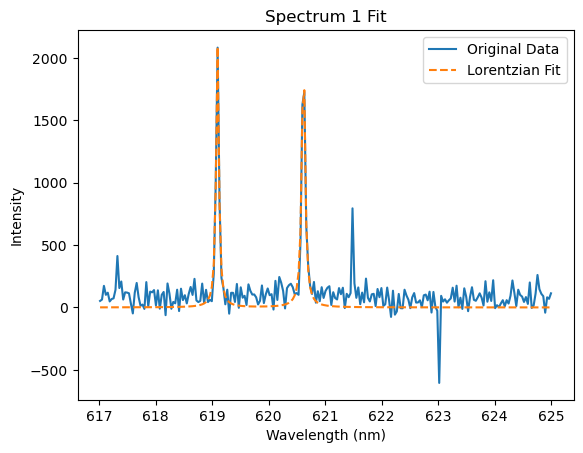

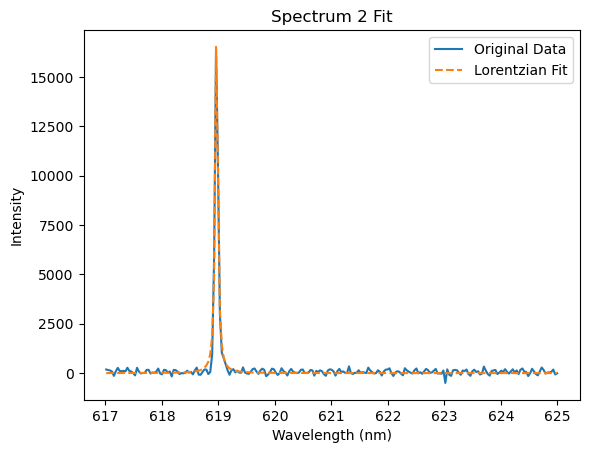

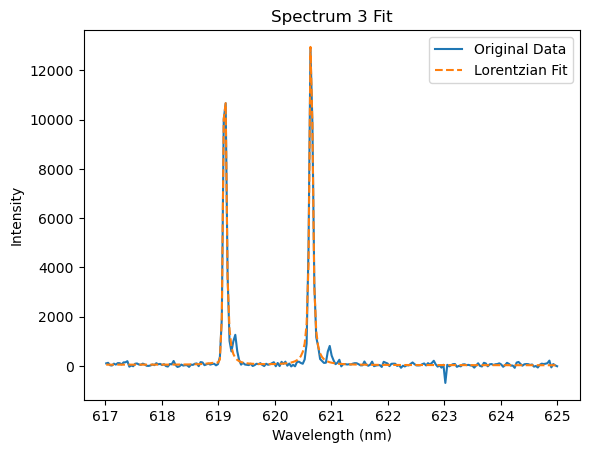

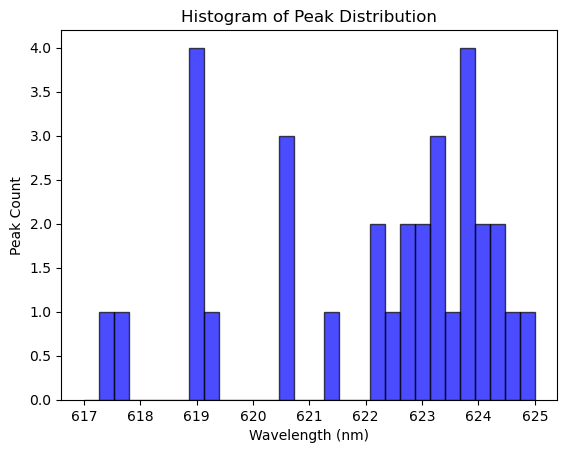

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# Lorentzian function
def lorentzian(x, *params):
    y = np.zeros_like(x)
    num_lorentzians = len(params) // 3
    for i in range(num_lorentzians):
        A = params[3 * i]      # Amplitude
        x0 = params[3 * i + 1] # Center
        gamma = params[3 * i + 2] # Width
        y += A * (gamma**2 / ((x - x0)**2 + gamma**2))
    return y

# Stack the data vertically
if data_list:
    data_array = np.vstack(data_list)
    
    # Define wavelength range for zooming
    zoom_start = 617  # 620 nm
    zoom_end = 625    # 622 nm
    
    # Create a mask for the zoomed-in range
    mask = (wavelength >= zoom_start) & (wavelength <= zoom_end)
    zoom_wavelengths = wavelength[mask]
    
    # Plot the raw data
    plt.imshow(data_array[:, mask], aspect='auto', extent=[zoom_start, zoom_end, 0, len(data_list)],
               vmax=5000, interpolation='nearest')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('File Index')
    plt.colorbar(label='Intensity')
    plt.xlim(zoom_start, zoom_end)
    plt.show()
    
    peak_centers = []  # Store peak positions
    
    # Fit each spectrum with multiple Lorentzians
    for i, spectrum in enumerate(data_array[:5]):  # Process only first 5 for visualization
        zoomed_spectrum = spectrum[mask]
        
        # Identify peaks
        peaks, _ = find_peaks(zoomed_spectrum, height=800)
        peak_wavelengths = zoom_wavelengths[peaks]
        
        if len(peak_wavelengths) == 0:
            continue  # Skip if no peaks found
        
        # Initial guesses: Amplitudes, centers, widths
        initial_guess = []
        for peak in peaks:
            initial_guess += [zoomed_spectrum[peak], zoom_wavelengths[peak], 0.5]  # Adjust width
        
        try:
            popt, _ = curve_fit(lorentzian, zoom_wavelengths, zoomed_spectrum, p0=initial_guess, maxfev=10000)
            peak_centers.extend(popt[1::3])  # Extract peak positions
            
            # Plot the fit for first 5 spectra
            plt.figure()
            plt.plot(zoom_wavelengths, zoomed_spectrum, label='Original Data')
            plt.plot(zoom_wavelengths, lorentzian(zoom_wavelengths, *popt), label='Lorentzian Fit', linestyle='dashed')
            plt.xlabel('Wavelength (nm)')
            plt.ylabel('Intensity')
            plt.legend()
            plt.title(f'Spectrum {i} Fit')
            plt.show()
        except RuntimeError:
            print(f"Fit failed for spectrum {i}")
    
    # Plot histogram of peak distribution
    plt.hist(peak_centers, bins=30, range=(zoom_start, zoom_end), alpha=0.7, color='blue', edgecolor='black')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Peak Count')
    plt.title('Histogram of Peak Distribution')
    plt.show()
else:
    print("No data with peaks larger than 800 found.")
